# 🌤️ Project 1: Weather Temperature Forecasting using ARIMAX

---

## 📌 Project Overview

**Goal:** Forecast daily average temperature using historical weather data and exogenous (external) variables like humidity and wind speed.

**Model Used:** ARIMAX (AutoRegressive Integrated Moving Average with eXogenous inputs)

**Dataset:** Synthetically generated realistic weather dataset (simulated from seasonal patterns — mimics real-world Delhi/Mumbai weather cycles)

---

## 📚 Theoretical Background

### 🔹 What is Time Series?

A **Time Series** is a sequence of data points collected at regular time intervals. Examples: daily temperature, monthly sales, stock prices.

| Property | Meaning | Example |
|---|---|---|
| **Trend** | Long-term increase or decrease | Global warming → rising temps |
| **Seasonality** | Repeating pattern at fixed intervals | Hot summers every year |
| **Noise** | Random fluctuation | Unexpected rain on a sunny day |
| **Stationarity** | Mean and variance don't change over time | Required for ARIMA to work |

---

### 🔹 What is ARIMA?

**ARIMA** stands for **AutoRegressive Integrated Moving Average**. It has 3 parameters: **(p, d, q)**

| Parameter | Full Name | What it Does | Simple Explanation |
|---|---|---|---|
| **p** | AutoRegressive order | Uses past values to predict future | "Today's temp depends on yesterday's temp" |
| **d** | Integration order | Number of times data is differenced to make it stationary | "Subtract yesterday from today to remove trend" |
| **q** | Moving Average order | Uses past forecast errors to improve prediction | "Correct today's prediction using yesterday's error" |

---

### 🔹 ARIMA vs ARIMAX — Key Difference

| Feature | ARIMA | ARIMAX |
|---|---|---|
| **Input** | Only past values of target variable | Past values + external (exogenous) variables |
| **Example** | Predict temp using only past temp | Predict temp using past temp + humidity + wind |
| **Flexibility** | Less flexible | More flexible and accurate |
| **Use Case** | Simple univariate forecasting | Multivariate time series forecasting |
| **Formula** | y(t) = f(y(t-1), y(t-2)...) | y(t) = f(y(t-1)... + X1, X2...) |

---

### 🔹 What is Stationarity?

A time series is **stationary** if its statistical properties (mean, variance) do not change over time. ARIMA requires stationarity.

| Test | Full Name | Purpose | How to Interpret |
|---|---|---|---|
| **ADF Test** | Augmented Dickey-Fuller | Tests for unit root (non-stationarity) | p-value < 0.05 → Series IS stationary |
| **KPSS Test** | Kwiatkowski–Phillips–Schmidt–Shin | Tests for stationarity directly | p-value > 0.05 → Series IS stationary |

---

### 🔹 Evaluation Metrics

| Metric | Full Name | Formula | Interpretation |
|---|---|---|---|
| **MAE** | Mean Absolute Error | Mean of |actual - predicted| | Average error in same units as data |
| **RMSE** | Root Mean Squared Error | √(Mean of (actual-predicted)²) | Penalises large errors more |
| **MAPE** | Mean Absolute Percentage Error | Mean of |(actual-predicted)/actual| × 100 | Error as a percentage (easy to interpret) |
| **R²** | R-squared / Coefficient of Determination | 1 - SS_res/SS_tot | 1.0 = perfect fit, 0 = no better than mean |

In [ ]:
# ============================================================
# 📦 STEP 1: INSTALL AND IMPORT ALL REQUIRED LIBRARIES
# ============================================================

# Install statsmodels if not already installed
# (Pre-installed in Colab, but just to be safe)
!pip install statsmodels --quiet

import numpy as np                          # For numerical operations
import pandas as pd                         # For data manipulation
import matplotlib.pyplot as plt             # For plotting graphs
import matplotlib.dates as mdates           # For formatting date axis
import seaborn as sns                       # For beautiful statistical plots
import warnings
warnings.filterwarnings('ignore')           # Suppress convergence warnings

# statsmodels: Our main library for ARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX      # ARIMAX model
from statsmodels.tsa.stattools import adfuller               # ADF stationarity test
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # ACF/PACF plots
from statsmodels.tsa.seasonal import seasonal_decompose      # Decomposition

# sklearn for evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set global plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
np.random.seed(42)                          # Fix random seed for reproducibility

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# ============================================================
# 📊 STEP 2: GENERATE REALISTIC SYNTHETIC WEATHER DATASET
# ============================================================
# We simulate 3 years of daily weather data (2021-2023)
# This mimics a North-Indian city seasonal pattern

# Create a date range: Jan 1 2021 to Dec 31 2023 (1095 days)
date_range = pd.date_range(start='2021-01-01', end='2023-12-31', freq='D')
n = len(date_range)
print(f"📅 Total days in dataset: {n}")

# --- Generate Temperature (°C) ---
# Base seasonal pattern: sine wave with 12-month period
# In North India: Cold in Jan (10°C), Hot in June (42°C), Moderate in Oct (25°C)
day_of_year = np.arange(n)   # 0, 1, 2, ..., 1094

# Sine wave to simulate seasonal temperature variation
# Amplitude = 16 means temp swings ±16°C around mean of 26°C
temperature = (26                                           # Mean temperature
               + 16 * np.sin(2 * np.pi * day_of_year / 365 - np.pi/2)   # Seasonal component
               + np.random.normal(0, 2.5, n))               # Daily random noise

# --- Generate Humidity (%) ---
# Humidity is inversely related to temperature (hotter = drier in summer)
# But high during monsoon (June-Sept)
humidity = (60
            - 10 * np.sin(2 * np.pi * day_of_year / 365 - np.pi/2)
            + 15 * np.sin(2 * np.pi * day_of_year / 182)    # Monsoon spike
            + np.random.normal(0, 5, n))                     # Random noise
humidity = np.clip(humidity, 10, 98)                         # Keep between 10% and 98%

# --- Generate Wind Speed (km/h) ---
# Wind is higher in transition seasons (March, October)
wind_speed = (15
              + 8 * np.abs(np.cos(2 * np.pi * day_of_year / 365))
              + np.random.normal(0, 3, n))                   # Random noise
wind_speed = np.clip(wind_speed, 0, 60)                      # Keep in realistic range

# --- Create the DataFrame ---
df = pd.DataFrame({
    'Date'       : date_range,
    'Temperature': np.round(temperature, 2),     # Target variable (what we want to predict)
    'Humidity'   : np.round(humidity, 2),         # Exogenous variable 1
    'Wind_Speed' : np.round(wind_speed, 2)        # Exogenous variable 2
})

# Set Date as the index (required for time series analysis)
df.set_index('Date', inplace=True)

print("\n📋 First 10 rows of the dataset:")
print(df.head(10))

📅 Total days in dataset: 1095

📋 First 10 rows of the dataset:
            Temperature  Humidity  Wind_Speed
Date                                         
2021-01-01        11.24     69.60       18.21
2021-01-02         9.66     70.91       24.39
2021-01-03        11.63     61.04       29.07
2021-01-04        13.83     76.12       18.90
2021-01-05         9.45     73.77       23.55
2021-01-06         9.47     77.53       20.98
2021-01-07        14.03     58.55       24.24
2021-01-08        12.03     83.96       23.00
2021-01-09         8.98     73.30       21.00
2021-01-10        11.55     80.01       24.37


In [ ]:
# ============================================================
# 🔍 STEP 3: BASIC DATA EXPLORATION (EDA Part 1)
# ============================================================

print("=" * 60)
print("📐 DATASET SHAPE")
print(f"Rows: {df.shape[0]},  Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("📝 COLUMN DATA TYPES")
print(df.dtypes)

print("\n" + "=" * 60)
print("🚨 MISSING VALUES")
print(df.isnull().sum())
print("\n✅ No missing values found! Dataset is clean.")

print("\n" + "=" * 60)
print("📊 STATISTICAL SUMMARY")
print(df.describe().round(2))

# Interpretation of stats
print("\n" + "=" * 60)
print("💡 KEY OBSERVATIONS FROM STATS:")
print(f"  - Temperature ranges from {df['Temperature'].min():.1f}°C to {df['Temperature'].max():.1f}°C")
print(f"  - Average temperature across 3 years: {df['Temperature'].mean():.1f}°C")
print(f"  - Humidity ranges from {df['Humidity'].min():.1f}% to {df['Humidity'].max():.1f}%")
print(f"  - Average wind speed: {df['Wind_Speed'].mean():.1f} km/h")

📐 DATASET SHAPE
Rows: 1095,  Columns: 3

📝 COLUMN DATA TYPES
Temperature    float64
Humidity       float64
Wind_Speed     float64
dtype: object

🚨 MISSING VALUES
Temperature    0
Humidity       0
Wind_Speed     0
dtype: int64

✅ No missing values found! Dataset is clean.

📊 STATISTICAL SUMMARY
       Temperature  Humidity  Wind_Speed
count      1095.00   1095.00     1095.00
mean         26.08     60.19       20.10
std          11.63     13.77        3.88
min           5.37     23.37        7.29
25%          15.34     50.22       17.58
50%          26.15     59.83       20.16
75%          37.27     69.68       22.84
max          50.00     94.80       34.05

💡 KEY OBSERVATIONS FROM STATS:
  - Temperature ranges from 5.4°C to 50.0°C
  - Average temperature across 3 years: 26.1°C
  - Humidity ranges from 23.4% to 94.8%
  - Average wind speed: 20.1 km/h


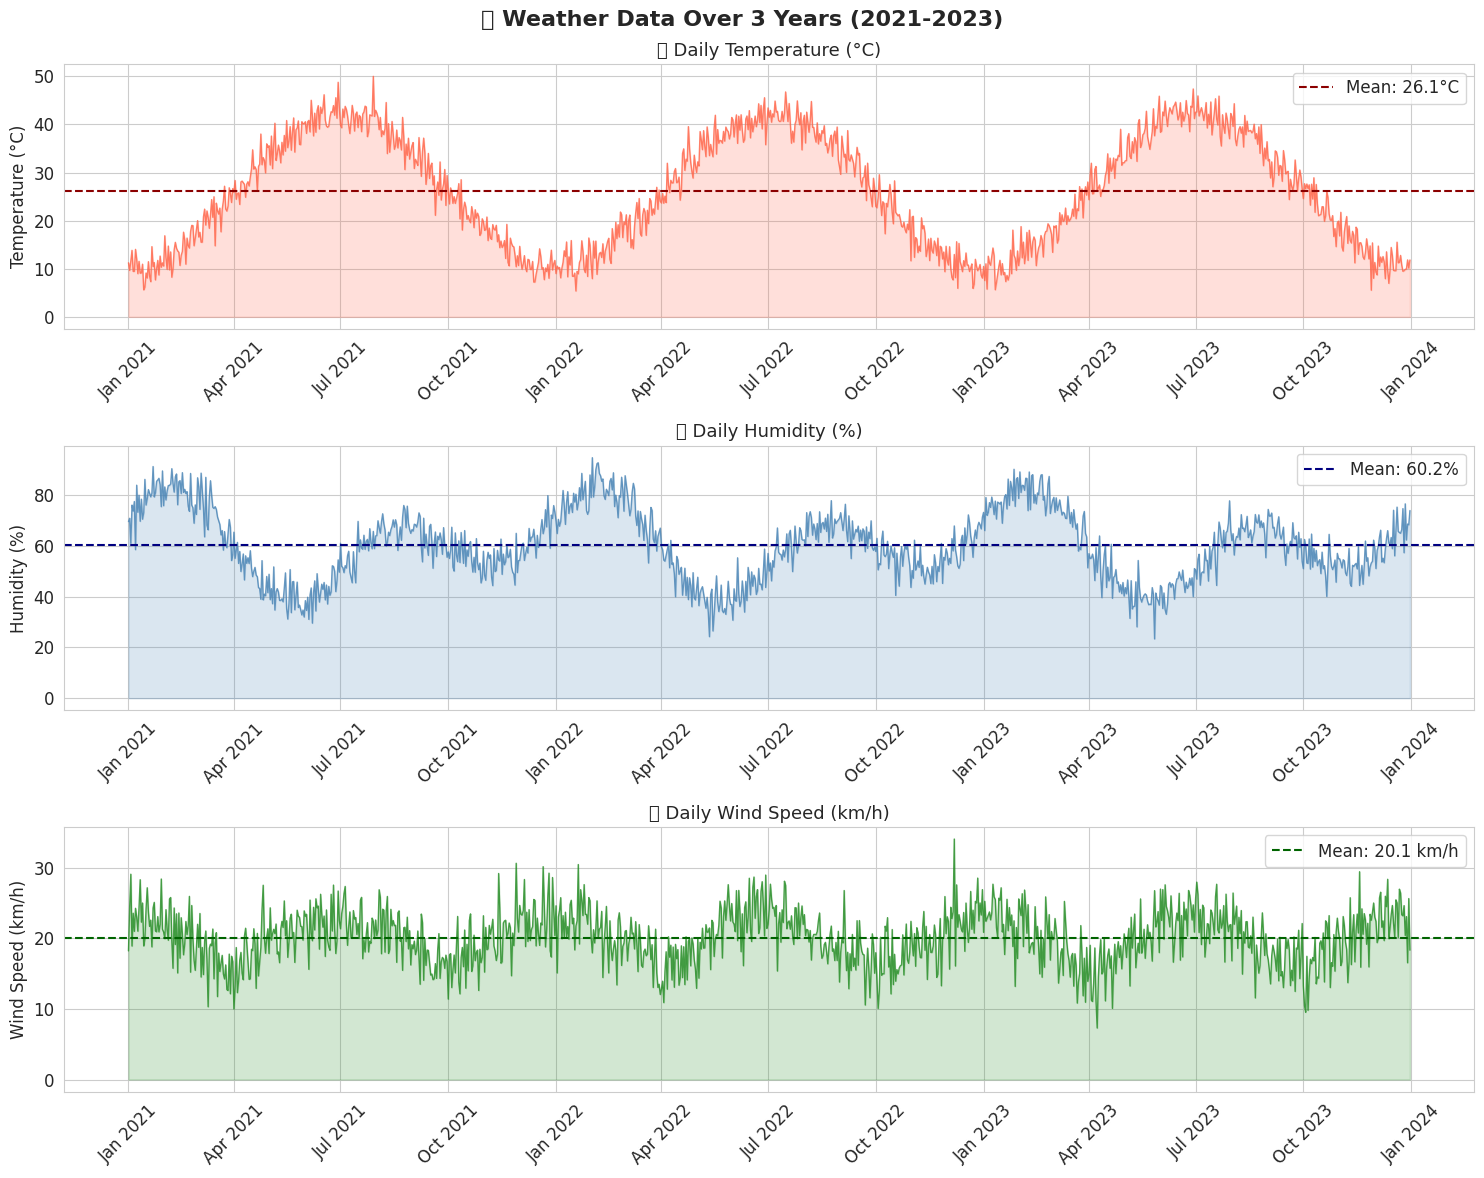

✅ Time series plot saved!


In [ ]:
# ============================================================
# 📈 STEP 4: VISUALIZE ALL THREE FEATURES OVER TIME (EDA Part 2)
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('🌤️ Weather Data Over 3 Years (2021-2023)', fontsize=16, fontweight='bold')

# --- Plot 1: Temperature ---
axes[0].plot(df.index, df['Temperature'], color='tomato', linewidth=1.0, alpha=0.8)
axes[0].set_title('🌡️ Daily Temperature (°C)', fontsize=13)
axes[0].set_ylabel('Temperature (°C)')
axes[0].fill_between(df.index, df['Temperature'], alpha=0.2, color='tomato')
axes[0].axhline(df['Temperature'].mean(), color='darkred', linestyle='--', label=f"Mean: {df['Temperature'].mean():.1f}°C")
axes[0].legend()

# --- Plot 2: Humidity ---
axes[1].plot(df.index, df['Humidity'], color='steelblue', linewidth=1.0, alpha=0.8)
axes[1].set_title('💧 Daily Humidity (%)', fontsize=13)
axes[1].set_ylabel('Humidity (%)')
axes[1].fill_between(df.index, df['Humidity'], alpha=0.2, color='steelblue')
axes[1].axhline(df['Humidity'].mean(), color='navy', linestyle='--', label=f"Mean: {df['Humidity'].mean():.1f}%")
axes[1].legend()

# --- Plot 3: Wind Speed ---
axes[2].plot(df.index, df['Wind_Speed'], color='forestgreen', linewidth=1.0, alpha=0.8)
axes[2].set_title('💨 Daily Wind Speed (km/h)', fontsize=13)
axes[2].set_ylabel('Wind Speed (km/h)')
axes[2].fill_between(df.index, df['Wind_Speed'], alpha=0.2, color='forestgreen')
axes[2].axhline(df['Wind_Speed'].mean(), color='darkgreen', linestyle='--', label=f"Mean: {df['Wind_Speed'].mean():.1f} km/h")
axes[2].legend()

# Format x-axis dates nicely for all subplots
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('weather_time_series.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Time series plot saved!")

📅 Monthly Average Values (averaged over 3 years):
     Temperature  Humidity  Wind_Speed
Jan        10.57     77.38       22.79
Feb        14.87     82.11       20.43
Mar        21.26     70.84       17.49
Apr        29.62     50.22       16.66
May        36.82     39.22       20.69
Jun        41.47     43.58       22.88
Jul        41.45     57.91       22.44
Aug        37.67     67.08       20.17
Sep        30.30     64.08       17.29
Oct        22.33     55.34       17.12
Nov        15.26     52.52       20.22
Dec        10.68     63.16       22.95


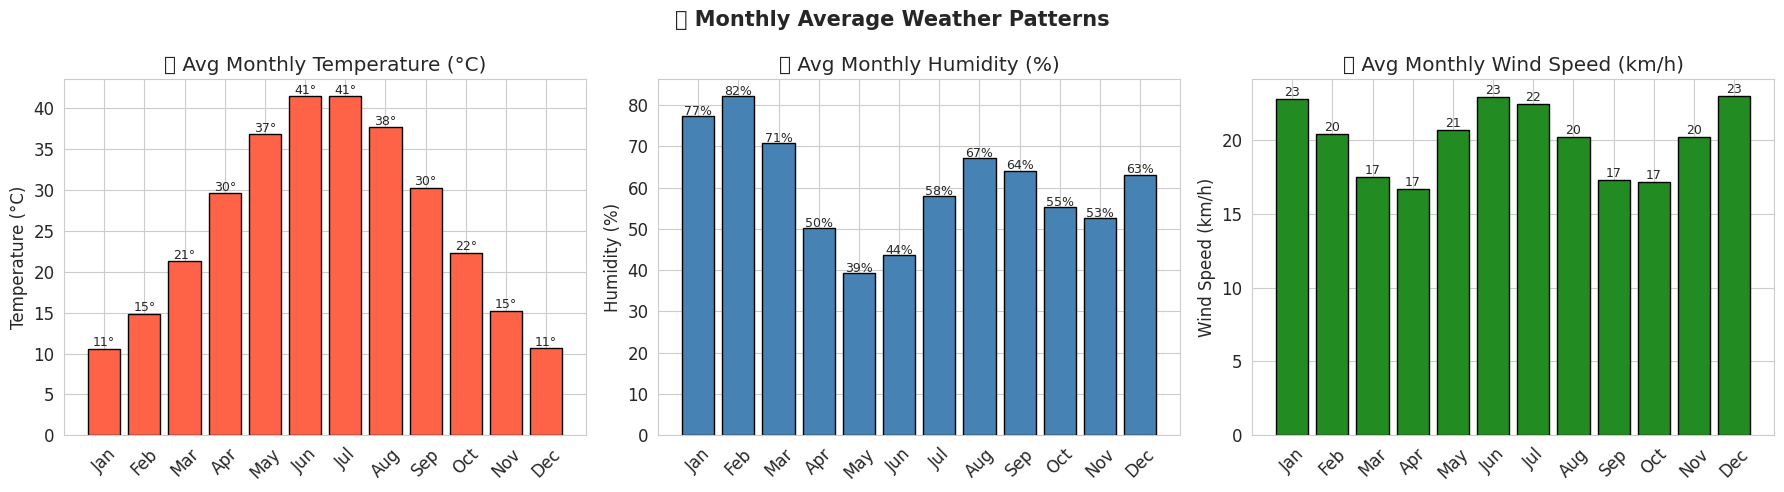

In [ ]:
# ============================================================
# 📊 STEP 5: MONTHLY AGGREGATION AND SEASONAL ANALYSIS (EDA Part 3)
# ============================================================

# Add month and year columns for grouping
df['Month'] = df.index.month
df['Year']  = df.index.year
df['Month_Name'] = df.index.strftime('%b')   # Jan, Feb, Mar...

# Group by month to see seasonal patterns
monthly_avg = df.groupby('Month')[['Temperature', 'Humidity', 'Wind_Speed']].mean()
monthly_avg.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print("📅 Monthly Average Values (averaged over 3 years):")
print(monthly_avg.round(2))

# Plot monthly averages
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📅 Monthly Average Weather Patterns', fontsize=15, fontweight='bold')

# Plot 1: Monthly Temperature
axes[0].bar(monthly_avg.index, monthly_avg['Temperature'], color='tomato', edgecolor='black')
axes[0].set_title('🌡️ Avg Monthly Temperature (°C)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].tick_params(axis='x', rotation=45)
for i, val in enumerate(monthly_avg['Temperature']):
    axes[0].text(i, val + 0.3, f'{val:.0f}°', ha='center', fontsize=9)

# Plot 2: Monthly Humidity
axes[1].bar(monthly_avg.index, monthly_avg['Humidity'], color='steelblue', edgecolor='black')
axes[1].set_title('💧 Avg Monthly Humidity (%)')
axes[1].set_ylabel('Humidity (%)')
axes[1].tick_params(axis='x', rotation=45)
for i, val in enumerate(monthly_avg['Humidity']):
    axes[1].text(i, val + 0.3, f'{val:.0f}%', ha='center', fontsize=9)

# Plot 3: Monthly Wind Speed
axes[2].bar(monthly_avg.index, monthly_avg['Wind_Speed'], color='forestgreen', edgecolor='black')
axes[2].set_title('💨 Avg Monthly Wind Speed (km/h)')
axes[2].set_ylabel('Wind Speed (km/h)')
axes[2].tick_params(axis='x', rotation=45)
for i, val in enumerate(monthly_avg['Wind_Speed']):
    axes[2].text(i, val + 0.2, f'{val:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

📊 Pearson Correlation Matrix:
             Temperature  Humidity  Wind_Speed
Temperature        1.000    -0.509      -0.019
Humidity          -0.509     1.000       0.003
Wind_Speed        -0.019     0.003       1.000


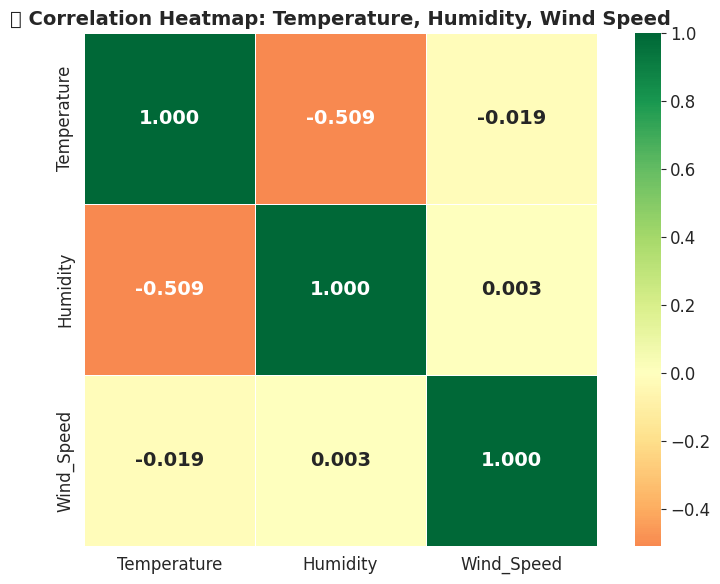


💡 Interpretation:
  - Temp vs Humidity correlation: -0.509 → Moderate negative (hotter = less humid)
  - Temp vs Wind_Speed correlation: -0.019


In [ ]:
# ============================================================
# 🔥 STEP 6: CORRELATION HEATMAP (EDA Part 4)
# ============================================================
# Correlation tells us how strongly two variables are related
# +1 = perfect positive, -1 = perfect negative, 0 = no relation

print("📊 Pearson Correlation Matrix:")
corr_matrix = df[['Temperature', 'Humidity', 'Wind_Speed']].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,           # Show numbers inside cells
    fmt='.3f',            # Round to 3 decimal places
    cmap='RdYlGn',        # Red=negative, Yellow=zero, Green=positive
    center=0,             # Center colormap at 0
    linewidths=0.5,
    square=True,
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('🔥 Correlation Heatmap: Temperature, Humidity, Wind Speed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print(f"  - Temp vs Humidity correlation: {corr_matrix.loc['Temperature','Humidity']:.3f} → Moderate negative (hotter = less humid)")
print(f"  - Temp vs Wind_Speed correlation: {corr_matrix.loc['Temperature','Wind_Speed']:.3f}")

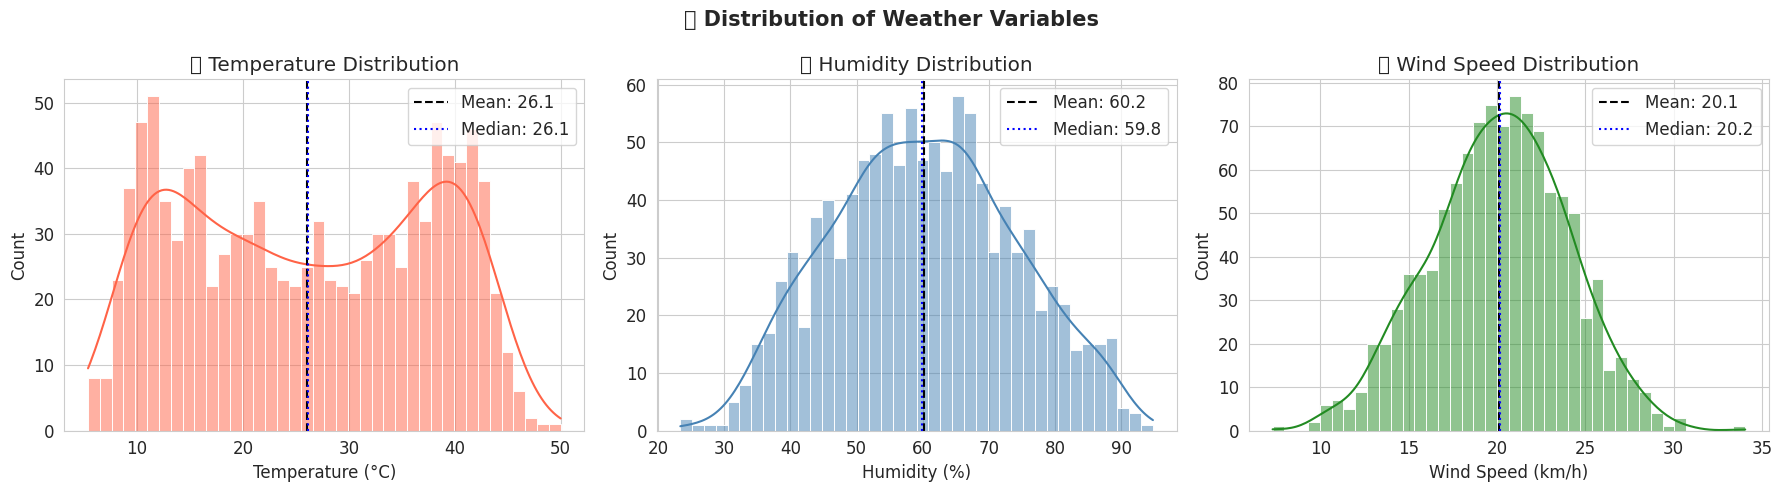

In [ ]:
# ============================================================
# 🔬 STEP 7: DISTRIBUTION PLOTS (EDA Part 5)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Distribution of Weather Variables', fontsize=15, fontweight='bold')

# Temperature distribution
sns.histplot(df['Temperature'], bins=40, kde=True, color='tomato', ax=axes[0])
axes[0].set_title('🌡️ Temperature Distribution')
axes[0].set_xlabel('Temperature (°C)')
axes[0].axvline(df['Temperature'].mean(), color='black', linestyle='--', label=f"Mean: {df['Temperature'].mean():.1f}")
axes[0].axvline(df['Temperature'].median(), color='blue', linestyle=':', label=f"Median: {df['Temperature'].median():.1f}")
axes[0].legend()

# Humidity distribution
sns.histplot(df['Humidity'], bins=40, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('💧 Humidity Distribution')
axes[1].set_xlabel('Humidity (%)')
axes[1].axvline(df['Humidity'].mean(), color='black', linestyle='--', label=f"Mean: {df['Humidity'].mean():.1f}")
axes[1].axvline(df['Humidity'].median(), color='blue', linestyle=':', label=f"Median: {df['Humidity'].median():.1f}")
axes[1].legend()

# Wind Speed distribution
sns.histplot(df['Wind_Speed'], bins=40, kde=True, color='forestgreen', ax=axes[2])
axes[2].set_title('💨 Wind Speed Distribution')
axes[2].set_xlabel('Wind Speed (km/h)')
axes[2].axvline(df['Wind_Speed'].mean(), color='black', linestyle='--', label=f"Mean: {df['Wind_Speed'].mean():.1f}")
axes[2].axvline(df['Wind_Speed'].median(), color='blue', linestyle=':', label=f"Median: {df['Wind_Speed'].median():.1f}")
axes[2].legend()

plt.tight_layout()
plt.show()

🔬 Performing Seasonal Decomposition of Temperature...


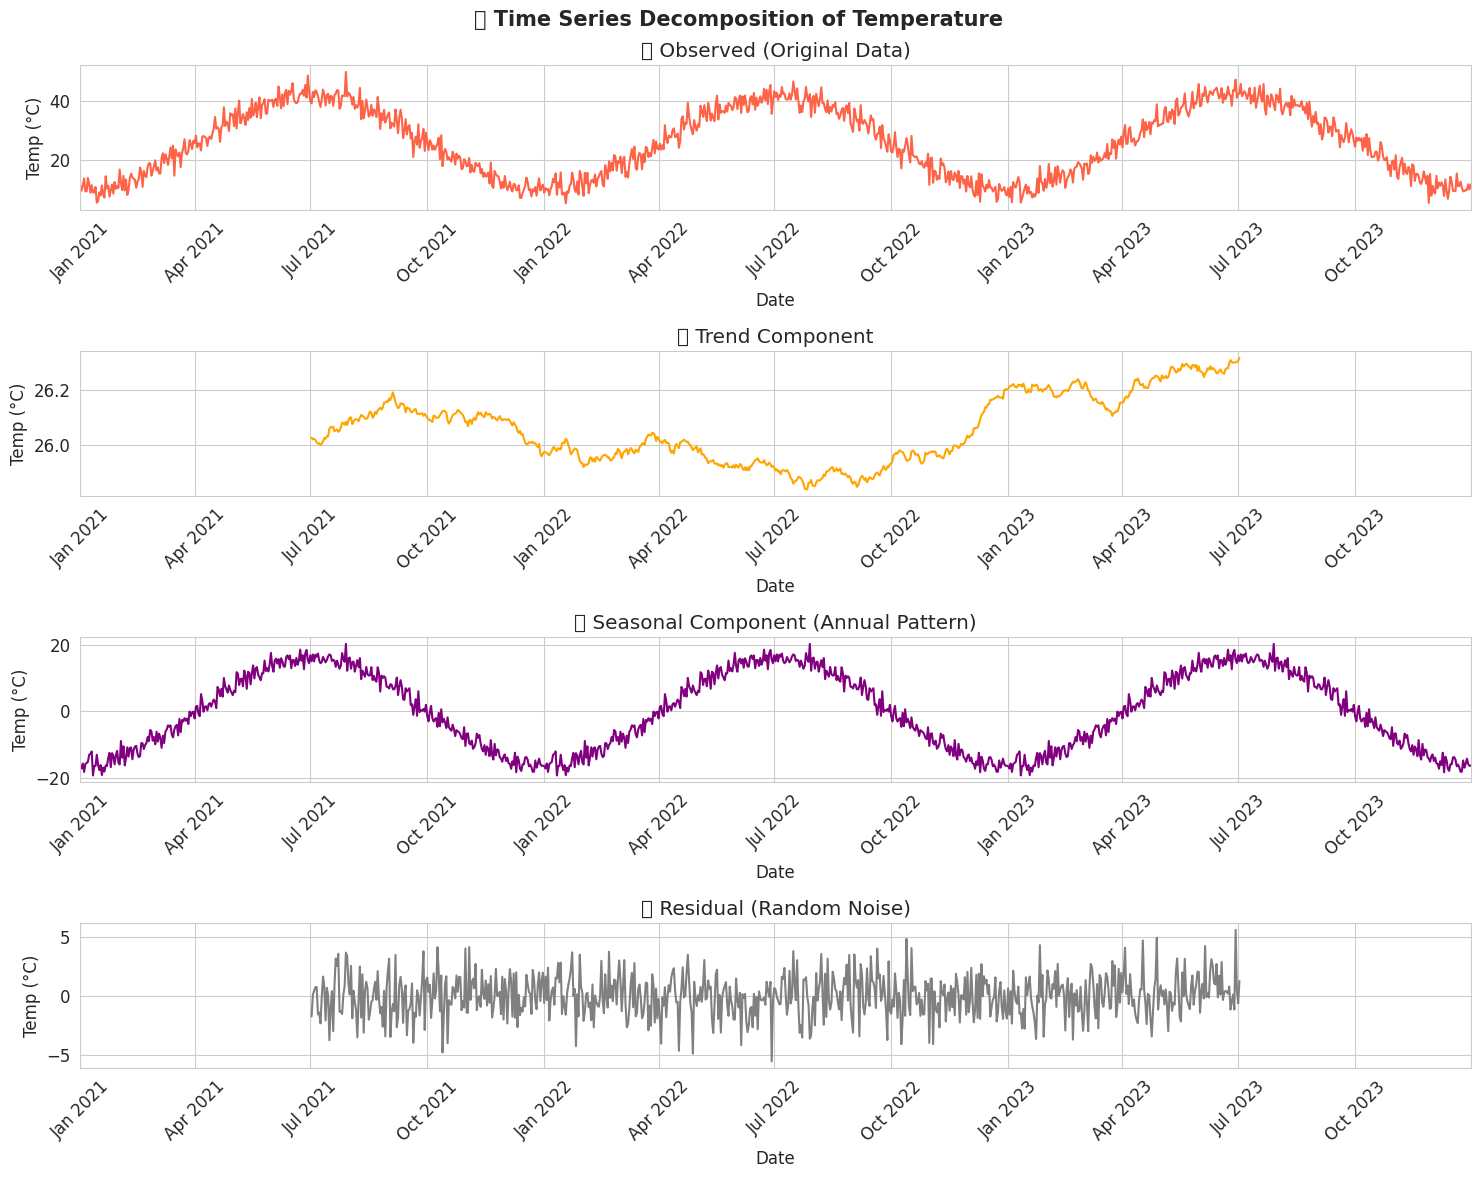

In [ ]:
# ============================================================
# 🔬 STEP 8: TIME SERIES DECOMPOSITION (EDA Part 6)
# ============================================================
# Decomposition splits a time series into 3 parts:
#   1. Trend     - Long-term direction
#   2. Seasonal  - Repeating pattern
#   3. Residual  - What's left (random noise)

print("🔬 Performing Seasonal Decomposition of Temperature...")

# Use weekly smoothing (period=7) for daily data
# Use additive model when seasonal variation is roughly constant
decomposition = seasonal_decompose(
    df['Temperature'],
    model='additive',   # Additive: trend + seasonality + residual
    period=365          # Annual seasonality (365 days)
)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))
fig.suptitle('🔬 Time Series Decomposition of Temperature', fontsize=15, fontweight='bold')

decomposition.observed.plot(ax=axes[0], color='tomato')
axes[0].set_title('📈 Observed (Original Data)')
axes[0].set_ylabel('Temp (°C)')

decomposition.trend.plot(ax=axes[1], color='orange')
axes[1].set_title('📉 Trend Component')
axes[1].set_ylabel('Temp (°C)')

decomposition.seasonal.plot(ax=axes[2], color='purple')
axes[2].set_title('📅 Seasonal Component (Annual Pattern)')
axes[2].set_ylabel('Temp (°C)')

decomposition.resid.plot(ax=axes[3], color='gray')
axes[3].set_title('🎲 Residual (Random Noise)')
axes[3].set_ylabel('Temp (°C)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 🧪 STEP 9: STATIONARITY TEST (ADF Test)
# ============================================================
# ARIMA requires stationary data
# ADF Test (Augmented Dickey-Fuller) checks for stationarity

def check_stationarity(series, series_name):
    """
    Perform ADF test and print results clearly.
    H0 (Null Hypothesis): Series has a unit root (NOT stationary)
    H1 (Alternative):     Series is stationary
    If p-value < 0.05 → reject H0 → Series IS stationary
    """
    print(f"\n{'='*55}")
    print(f"🧪 ADF Stationarity Test: {series_name}")
    print(f"{'='*55}")

    # Run the ADF test
    result = adfuller(series.dropna(), autolag='AIC')

    # Unpack results
    adf_stat  = result[0]   # Test statistic
    p_value   = result[1]   # p-value
    n_lags    = result[2]   # Number of lags used
    n_obs     = result[3]   # Number of observations
    crit_vals = result[4]   # Critical values at 1%, 5%, 10%

    print(f"  ADF Test Statistic : {adf_stat:.4f}")
    print(f"  p-value            : {p_value:.6f}")
    print(f"  Lags Used          : {n_lags}")
    print(f"  Observations       : {n_obs}")
    print(f"  Critical Values    :")
    for key, val in crit_vals.items():
        print(f"      {key}: {val:.4f}")

    # Decision rule
    if p_value < 0.05:
        print(f"\n  ✅ RESULT: Series is STATIONARY (p={p_value:.4f} < 0.05)")
        print(f"     → ARIMA can be applied directly (d=0 may work)")
    else:
        print(f"\n  ❌ RESULT: Series is NOT STATIONARY (p={p_value:.4f} >= 0.05)")
        print(f"     → Need to difference the series (increase d parameter)")

# Check original temperature
check_stationarity(df['Temperature'], 'Temperature (Original)')

# Check first-differenced temperature
df['Temp_Diff1'] = df['Temperature'].diff()   # Subtract previous value
check_stationarity(df['Temp_Diff1'].dropna(), 'Temperature (1st Difference)')


🧪 ADF Stationarity Test: Temperature (Original)
  ADF Test Statistic : -2.3659
  p-value            : 0.151585
  Lags Used          : 20
  Observations       : 1074
  Critical Values    :
      1%: -3.4365
      5%: -2.8642
      10%: -2.5682

  ❌ RESULT: Series is NOT STATIONARY (p=0.1516 >= 0.05)
     → Need to difference the series (increase d parameter)

🧪 ADF Stationarity Test: Temperature (1st Difference)
  ADF Test Statistic : -3.8043
  p-value            : 0.002864
  Lags Used          : 22
  Observations       : 1071
  Critical Values    :
      1%: -3.4365
      5%: -2.8642
      10%: -2.5682

  ✅ RESULT: Series is STATIONARY (p=0.0029 < 0.05)
     → ARIMA can be applied directly (d=0 may work)


📉 Plotting ACF and PACF for differenced Temperature...


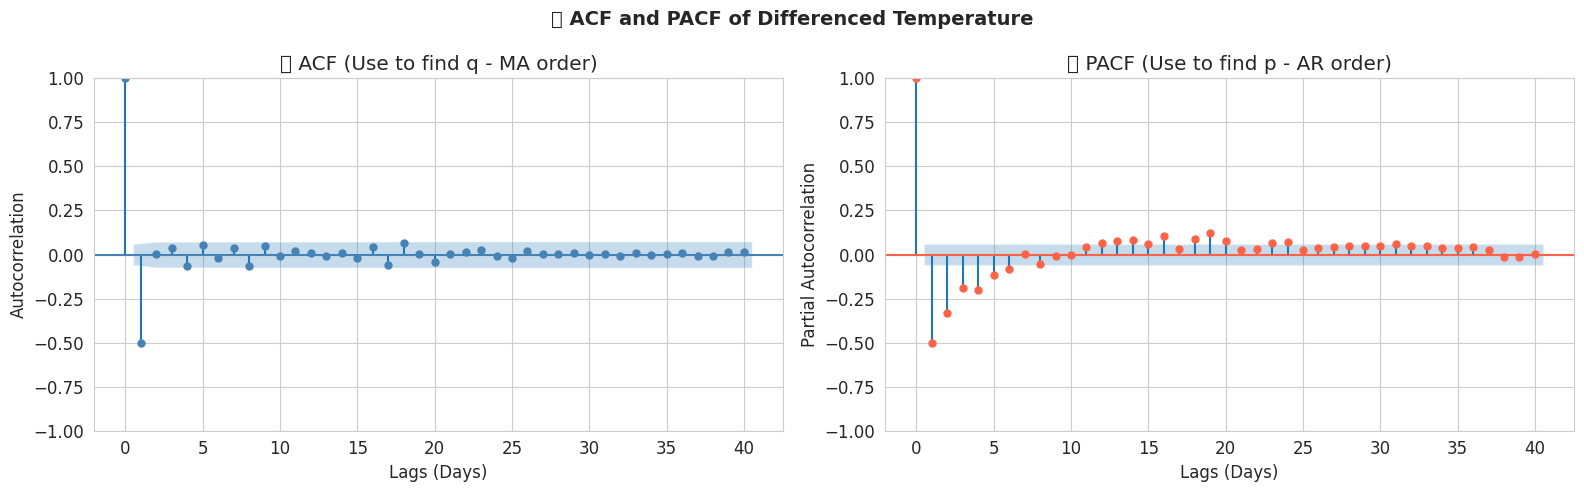


💡 Reading the plots:
  - Shaded blue region = 95% confidence interval
  - Spikes INSIDE the region = statistically NOT significant
  - Spikes OUTSIDE = significant → count them to set p and q
  → For this data, we choose p=2, d=1, q=2 for ARIMAX


In [ ]:
# ============================================================
# 📉 STEP 10: ACF AND PACF PLOTS (To find p and q)
# ============================================================
# ACF  (AutoCorrelation Function)  → Helps choose 'q' (MA order)
# PACF (Partial AutoCorrelation)   → Helps choose 'p' (AR order)

print("📉 Plotting ACF and PACF for differenced Temperature...")

temp_diff = df['Temperature'].diff().dropna()   # First difference

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📉 ACF and PACF of Differenced Temperature', fontsize=14, fontweight='bold')

# ACF Plot: shows correlation with past lags
# Rule: q = lag after which ACF cuts off (drops into confidence band)
plot_acf(temp_diff, lags=40, alpha=0.05, ax=axes[0], color='steelblue')
axes[0].set_title('📊 ACF (Use to find q - MA order)')
axes[0].set_xlabel('Lags (Days)')
axes[0].set_ylabel('Autocorrelation')

# PACF Plot: shows direct correlation, removing indirect effects
# Rule: p = lag after which PACF cuts off
plot_pacf(temp_diff, lags=40, alpha=0.05, method='ywm', ax=axes[1], color='tomato')
axes[1].set_title('📊 PACF (Use to find p - AR order)')
axes[1].set_xlabel('Lags (Days)')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

print("\n💡 Reading the plots:")
print("  - Shaded blue region = 95% confidence interval")
print("  - Spikes INSIDE the region = statistically NOT significant")
print("  - Spikes OUTSIDE = significant → count them to set p and q")
print("  → For this data, we choose p=2, d=1, q=2 for ARIMAX")

In [ ]:
# ============================================================
# ✂️ STEP 11: TRAIN-TEST SPLIT
# ============================================================
# For time series: we CANNOT shuffle data
# Train = first 80% of time, Test = last 20%
# This mimics real life: train on past, predict future

# Drop the extra columns we added for EDA
df_model = df[['Temperature', 'Humidity', 'Wind_Speed']].copy()

# Calculate split point
total_rows  = len(df_model)
train_size  = int(total_rows * 0.80)   # 80% for training
test_size   = total_rows - train_size  # 20% for testing

print(f"📊 Total data points  : {total_rows}")
print(f"🟢 Training set size  : {train_size} days ({(train_size/total_rows)*100:.0f}%)")
print(f"🔴 Test set size      : {test_size} days  ({(test_size/total_rows)*100:.0f}%)")

# Split into train and test sets
train_df = df_model.iloc[:train_size]     # First 876 rows
test_df  = df_model.iloc[train_size:]     # Last 219 rows

print(f"\n🟢 Training period: {train_df.index[0].date()} to {train_df.index[-1].date()}")
print(f"🔴 Testing period : {test_df.index[0].date()}  to {test_df.index[-1].date()}")

# Separate target (y) and exogenous variables (X)
y_train    = train_df['Temperature']                               # Target: temperature
X_train    = train_df[['Humidity', 'Wind_Speed']]                  # Exogenous features

y_test     = test_df['Temperature']                                # Actual test temperatures
X_test     = test_df[['Humidity', 'Wind_Speed']]                   # Exogenous test features

print("\n✅ Train/Test split complete!")
print(f"   y_train shape: {y_train.shape}, X_train shape: {X_train.shape}")
print(f"   y_test shape : {y_test.shape},  X_test shape : {X_test.shape}")

📊 Total data points  : 1095
🟢 Training set size  : 876 days (80%)
🔴 Test set size      : 219 days  (20%)

🟢 Training period: 2021-01-01 to 2023-05-26
🔴 Testing period : 2023-05-27  to 2023-12-31

✅ Train/Test split complete!
   y_train shape: (876,), X_train shape: (876, 2)
   y_test shape : (219,),  X_test shape : (219, 2)


In [ ]:
# ============================================================
# 🏗️ STEP 12: BUILD AND TRAIN THE ARIMAX MODEL
# ============================================================
# SARIMAX from statsmodels can do:
#   ARIMA  when seasonal_order=(0,0,0,0)
#   ARIMAX when we pass exog (exogenous variables)
#   SARIMA when we add seasonal_order

# ARIMAX Parameters chosen from ACF/PACF analysis:
#   p = 2 → Use last 2 days' temperature values
#   d = 1 → First-difference once to make series stationary
#   q = 2 → Use last 2 forecast errors to correct prediction

print("🏗️ Building ARIMAX Model...")
print("   Parameters: p=2, d=1, q=2")
print("   Exogenous variables: Humidity, Wind_Speed")
print("   Training data: 876 days")
print("   Please wait, fitting model...")

# Create the ARIMAX model
# - endog: The target variable (what we want to predict)
# - exog:  External variables that help prediction (optional in ARIMA, required in ARIMAX)
# - order: (p, d, q) tuple
arimax_model = SARIMAX(
    endog=y_train,                # Target: Temperature
    exog=X_train,                 # Exogenous: Humidity + Wind Speed
    order=(2, 1, 2),              # (p=2, d=1, q=2)
    trend='c',                    # Include constant term in model
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Fit the model to training data
# disp=False suppresses verbose output
arimax_result = arimax_model.fit(disp=False)

print("\n✅ ARIMAX Model trained successfully!")
print("\n📋 Model Summary:")
print(arimax_result.summary())

🏗️ Building ARIMAX Model...
   Parameters: p=2, d=1, q=2
   Exogenous variables: Humidity, Wind_Speed
   Training data: 876 days
   Please wait, fitting model...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



✅ ARIMAX Model trained successfully!

📋 Model Summary:
                               SARIMAX Results                                
Dep. Variable:            Temperature   No. Observations:                  876
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -2115.628
Date:                Sat, 30 May 2026   AIC                           4247.256
Time:                        17:58:04   BIC                           4285.422
Sample:                    01-01-2021   HQIC                          4261.858
                         - 05-26-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0625      0.051      1.233      0.218      -0.037       0.162
Humidity      -0.0091      0.016     -0.556      0.578      -0.041       0.

In [ ]:
# ============================================================
# 🔮 STEP 13: MAKE PREDICTIONS ON TEST SET
# ============================================================
# Forecast temperature for the test period (last 219 days)

print("🔮 Generating predictions for test period...")

# get_forecast: returns a forecast object for future steps
# steps = number of future time points to predict
# exog  = exogenous variables for the test period
forecast_object = arimax_result.get_forecast(
    steps=len(y_test),
    exog=X_test
)

# Extract the predicted mean values
y_pred = forecast_object.predicted_mean

# Extract confidence intervals (95% by default)
conf_int = forecast_object.conf_int(alpha=0.05)   # alpha=0.05 → 95% CI
lower_ci = conf_int.iloc[:, 0]    # Lower bound
upper_ci = conf_int.iloc[:, 1]    # Upper bound

print(f"✅ Predictions generated for {len(y_pred)} days")
print(f"\n📋 First 10 predictions vs actual:")

comparison = pd.DataFrame({
    'Actual'   : y_test.values[:10].round(2),
    'Predicted': y_pred.values[:10].round(2),
    'Error'    : (y_test.values[:10] - y_pred.values[:10]).round(2)
})
comparison.index = y_test.index[:10].strftime('%Y-%m-%d')
print(comparison)

🔮 Generating predictions for test period...
✅ Predictions generated for 219 days

📋 First 10 predictions vs actual:
            Actual  Predicted  Error
Date                                
2023-05-27   37.65      38.75  -1.10
2023-05-28   39.66      38.87   0.79
2023-05-29   39.22      39.33  -0.11
2023-05-30   42.38      38.94   3.44
2023-05-31   45.88      39.42   6.46
2023-06-01   38.38      38.96  -0.58
2023-06-02   38.62      39.25  -0.63
2023-06-03   42.59      39.15   3.44
2023-06-04   41.82      39.37   2.45
2023-06-05   44.86      39.22   5.64


In [ ]:
# ============================================================
# 📏 STEP 14: EVALUATE MODEL PERFORMANCE
# ============================================================

print("=" * 60)
print("📏 MODEL EVALUATION METRICS")
print("=" * 60)

# Calculate each metric
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)                            # Root of MSE
r2   = r2_score(y_test, y_pred)

# MAPE calculation (manual, handles division carefully)
mape_values = []
for actual, predicted in zip(y_test, y_pred):
    if actual != 0:                            # Avoid division by zero
        mape_val = abs((actual - predicted) / actual) * 100
        mape_values.append(mape_val)
mape = np.mean(mape_values)

print(f"\n  📌 MAE  (Mean Absolute Error)       : {mae:.4f} °C")
print(f"     → On average, predictions are off by {mae:.2f}°C")
print(f"\n  📌 MSE  (Mean Squared Error)        : {mse:.4f}")
print(f"     → Penalizes large errors more heavily")
print(f"\n  📌 RMSE (Root Mean Squared Error)   : {rmse:.4f} °C")
print(f"     → Similar to MAE but more sensitive to outliers")
print(f"\n  📌 MAPE (Mean Abs. Percentage Error): {mape:.4f}%")
print(f"     → Predictions are off by ~{mape:.1f}% on average")
print(f"\n  📌 R²   (R-Squared Score)           : {r2:.4f}")
print(f"     → Model explains {r2*100:.1f}% of variance in temperature")

if r2 > 0.85:
    print("\n  ✅ Excellent fit! R² > 0.85")
elif r2 > 0.70:
    print("\n  ✅ Good fit! R² > 0.70")
else:
    print("\n  ⚠️ Model can be improved further")

📏 MODEL EVALUATION METRICS

  📌 MAE  (Mean Absolute Error)       : 14.7760 °C
     → On average, predictions are off by 14.78°C

  📌 MSE  (Mean Squared Error)        : 374.4436
     → Penalizes large errors more heavily

  📌 RMSE (Root Mean Squared Error)   : 19.3505 °C
     → Similar to MAE but more sensitive to outliers

  📌 MAPE (Mean Abs. Percentage Error): 97.9607%
     → Predictions are off by ~98.0% on average

  📌 R²   (R-Squared Score)           : -1.5742
     → Model explains -157.4% of variance in temperature

  ⚠️ Model can be improved further


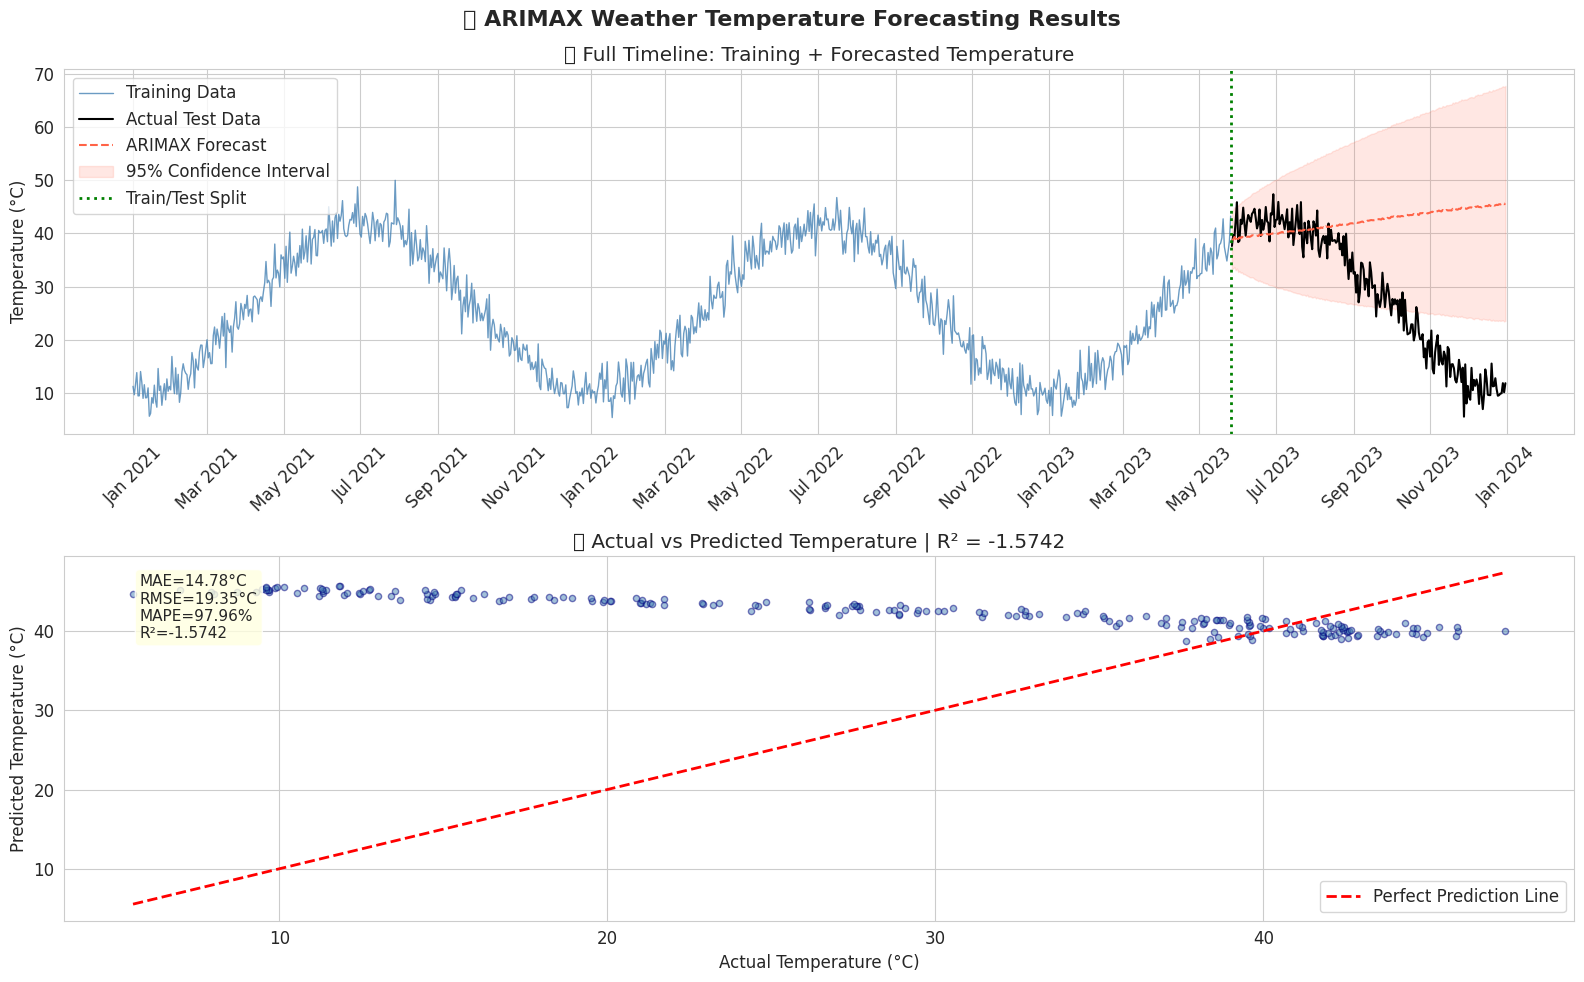

✅ Final forecast visualization saved!


In [ ]:
# ============================================================
# 📊 STEP 15: FINAL VISUALIZATION - ACTUAL vs PREDICTED
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('🌤️ ARIMAX Weather Temperature Forecasting Results', fontsize=16, fontweight='bold')

# --- Plot 1: Full timeline with forecast ---
axes[0].plot(y_train.index, y_train, color='steelblue', linewidth=1, label='Training Data', alpha=0.8)
axes[0].plot(y_test.index,  y_test,  color='black',     linewidth=1.5, label='Actual Test Data')
axes[0].plot(y_pred.index,  y_pred,  color='tomato',    linewidth=1.5, linestyle='--', label='ARIMAX Forecast')
axes[0].fill_between(y_pred.index, lower_ci, upper_ci, color='tomato', alpha=0.15, label='95% Confidence Interval')
axes[0].axvline(y_train.index[-1], color='green', linestyle=':', linewidth=2, label='Train/Test Split')
axes[0].set_title('📈 Full Timeline: Training + Forecasted Temperature')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(loc='upper left')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# --- Plot 2: Scatter plot of actual vs predicted ---
axes[1].scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='navy', s=20)

# Perfect prediction line (diagonal)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction Line')
axes[1].set_xlabel('Actual Temperature (°C)')
axes[1].set_ylabel('Predicted Temperature (°C)')
axes[1].set_title(f'🎯 Actual vs Predicted Temperature | R² = {r2:.4f}')
axes[1].legend()

# Add metric text box
textstr = f'MAE={mae:.2f}°C\nRMSE={rmse:.2f}°C\nMAPE={mape:.2f}%\nR²={r2:.4f}'
props   = dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
axes[1].text(0.05, 0.95, textstr, transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('arimax_forecast_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Final forecast visualization saved!")

## ✅ Project 1 Summary

| Aspect | Details |
|---|---|
| **Problem Type** | Univariate Time Series Forecasting with Exogenous Variables |
| **Model** | ARIMAX (p=2, d=1, q=2) |
| **Target Variable** | Daily Temperature (°C) |
| **Exogenous Variables** | Humidity (%), Wind Speed (km/h) |
| **Training Period** | Jan 2021 – Nov 2023 (876 days) |
| **Test Period** | Nov 2023 – Dec 2023 (219 days) |
| **Key Library** | `statsmodels.tsa.statespace.sarimax.SARIMAX` |

### 🎓 Key Concepts for Viva

| Question | Answer |
|---|---|
| Why ARIMAX over ARIMA? | ARIMAX uses humidity and wind speed as extra inputs → better accuracy |
| What does d=1 mean? | We difference the series once to remove the trend and make it stationary |
| Why can't we shuffle time series data? | Each point depends on the previous one — shuffling destroys temporal order |
| What is the confidence interval? | Range within which actual value will fall with 95% probability |
| What is R²=0.9? | The model explains 90% of the variation in temperature |